# Eval: StableLM2-1.6B vs Vintern-LoRA Fine-tuned

So sánh **StableLM2-1.6B** (Stability AI) với **Vintern-1B-v2 LoRA Fine-tuned** trên **700 samples test**.

- Kết quả **Vintern-LoRA** load từ `debug_vintern_lora.csv` (đã eval sẵn)
- **StableLM2-1.6B** eval trực tiếp trong notebook, dùng **T4 GPU**
- Metrics: BLEU · METEOR · ROUGE-1 · ROUGE-2 · ROUGE-L · BERTScore

> Model: `stabilityai/stablelm-2-1_6b-chat` — model mở, không cần accept license đặc biệt.

## Cell 1 — Cài thư viện

> Sau cell này hãy **Restart kernel** rồi chạy tiếp từ Cell 2.

In [1]:
# import subprocess, sys

# def pip(args):
#     subprocess.run([sys.executable, '-m', 'pip'] + args,
#                    check=True, capture_output=True)

# pip(['install', '-q', 'tokenizers>=0.20.0', 'transformers>=4.45.0', '--upgrade'])
# pip(['install', '-q', 'packaging', 'datasets', 'timm', 'einops', 'peft',
#      'bitsandbytes', 'hf_transfer', 'huggingface_hub'])
# pip(['install', '-q', 'rouge_score', 'evaluate', 'underthesea', 'bert-score', 'nltk'])
# pip(['uninstall', 'numpy', '-y'])
# pip(['install', '-q', 'numpy==1.26.4'])

# import transformers, tokenizers, numpy as np
# print(f'transformers : {transformers.__version__}')
# print(f'tokenizers   : {tokenizers.__version__}')
# print(f'numpy        : {np.__version__}')
# print('\n✅ Done — Restart kernel truoc khi chay Cell 2!')

## Cell 2 — Config

In [2]:
from pathlib import Path
import torch, os

KAGGLE_WORKING         = Path('/kaggle/working')
SRC_DATASET            = '/kaggle/input/datasets/maituananh511/test-dataset-chart-vqa/vi_chart_dataset'
DST_DATASET            = str(KAGGLE_WORKING / 'vi_chart_dataset')
VIETNAMESE_DATA_PATH   = Path('/kaggle/input/datasets/maituananh511/data-vietnamese/Data Vietnamese')
VIETNAMESE_IMAGES_PATH = VIETNAMESE_DATA_PATH / 'images'
VIETNAMESE_JSONL_PATH  = VIETNAMESE_DATA_PATH / 'viet_chart_vqa.jsonl'

STABLELM_DIR     = KAGGLE_WORKING / 'stablelm_model'
STABLELM_REPO_ID = 'stabilityai/stablelm-2-1_6b-chat'
VINTERN_LORA_CSV = Path('/kaggle/input/datasets/maituananh511/700-vinternlora-result/debug_vintern_lora.csv')
# Upload CSV thu cong thi doi sang:
# VINTERN_LORA_CSV = KAGGLE_WORKING / 'debug_vintern_lora.csv'

CHART_TEST_N   = 500
VIETNAMESE_N   = 200
EVAL_TOTAL     = CHART_TEST_N + VIETNAMESE_N
BATCH_SIZE     = 16   # giam xuong 8 neu OOM
MAX_NEW_TOKENS = 64   # du cho VQA answer ngan
METRICS        = ['bleu', 'meteor', 'rouge1', 'rouge2', 'rougeL', 'bertscore']

# Kiem tra GPU
n_gpu = torch.cuda.device_count()
print(f'GPU count: {n_gpu}')
for i in range(n_gpu):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} — {p.total_memory // 1024**3} GB')
print(f'\nEval target    : {EVAL_TOTAL} samples')
print(f'StableLM2 repo : {STABLELM_REPO_ID}')

GPU count: 2
  GPU 0: Tesla T4 — 14 GB
  GPU 1: Tesla T4 — 14 GB

Eval target    : 700 samples
StableLM2 repo : stabilityai/stablelm-2-1_6b-chat


## Cell 3 — Download StableLM2-1.6B

In [3]:
from huggingface_hub import snapshot_download
import shutil, os

# Xoa folder rong neu download do lan truoc
if STABLELM_DIR.exists() and not any(STABLELM_DIR.iterdir()):
    shutil.rmtree(str(STABLELM_DIR))
    print('Xoa folder rong')

if not STABLELM_DIR.exists():
    STABLELM_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Downloading {STABLELM_REPO_ID} ...')
    snapshot_download(
        repo_id=STABLELM_REPO_ID,
        local_dir=str(STABLELM_DIR),
        ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*'],
    )
    print('Download xong')
else:
    print(f'Model da co — {len(list(STABLELM_DIR.iterdir()))} files')

print('Files:', os.listdir(str(STABLELM_DIR))[:10])

Model da co — 14 files
Files: ['model-00001-of-00002.safetensors', 'config.json', 'vocab.json', 'merges.txt', 'model.safetensors.index.json', '.gitattributes', 'README.md', 'special_tokens_map.json', '.cache', 'generation_config.json']


## Cell 4 — Load dataset (700 samples)

In [4]:
from datasets import load_from_disk
from PIL import Image
import json, shutil, os

def is_dataset_complete(dst, src):
    if not os.path.exists(dst):
        return False
    src_files = {os.path.relpath(os.path.join(r, f), src)
                 for r, _, fs in os.walk(src) for f in fs}
    dst_files = {os.path.relpath(os.path.join(r, f), dst)
                 for r, _, fs in os.walk(dst) for f in fs}
    missing = src_files - dst_files
    if missing:
        print(f'Thieu {len(missing)} files')
        return False
    return True

if is_dataset_complete(DST_DATASET, SRC_DATASET):
    print('Dataset da copy day du, skip.')
else:
    if os.path.exists(DST_DATASET):
        shutil.rmtree(DST_DATASET)
    print('Copying dataset ...')
    shutil.copytree(SRC_DATASET, DST_DATASET)
    print('Copy xong.')

vi_chart_dataset = load_from_disk(DST_DATASET)
print(vi_chart_dataset)

vietnamese_records = []
with open(VIETNAMESE_JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            vietnamese_records.append(json.loads(line))
print(f'Vietnamese records: {len(vietnamese_records)} loaded')

Copying dataset ...
Copy xong.
DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'description', 'conversations', 'groundtruth'],
        num_rows: 100002
    })
    test: Dataset({
        features: ['id', 'image', 'description', 'conversations', 'groundtruth'],
        num_rows: 500
    })
})
Vietnamese records: 4957 loaded


## Cell 5 — Build eval_dataset

In [5]:
from PIL import Image

def normalize_turn(turn):
    if isinstance(turn, str):
        return {'role': 'assistant', 'content': turn}
    if isinstance(turn, dict):
        role = turn.get('role') or turn.get('from', '')
        if role in ('human', 'user'):      role = 'user'
        elif role in ('gpt', 'assistant'): role = 'assistant'
        for rk in ('assistant', 'user', 'human', 'gpt'):
            if rk in turn and 'content' not in turn and 'role' not in turn:
                role = 'assistant' if rk in ('assistant', 'gpt') else 'user'
                return {'role': role, 'content': str(turn[rk])}
        return {'role': role, 'content': str(turn.get('content') or turn.get('value', ''))}
    return {'role': 'assistant', 'content': str(turn)}

# Chart samples
chart_test_raw   = vi_chart_dataset['test']
chart_n          = min(CHART_TEST_N, len(chart_test_raw))
chart_test_items = [chart_test_raw[i] for i in range(chart_n)]
print(f'vi_chart test   : {chart_n} samples')

# Vietnamese samples
vn_test_items = []
for record in reversed(vietnamese_records):
    if len(vn_test_items) >= VIETNAMESE_N:
        break
    img_path = VIETNAMESE_IMAGES_PATH / record['image']
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f'Warning: {img_path}: {e}')
        continue
    convs = [normalize_turn(t) for t in record['conversations']]
    pairs = [(convs[i], convs[i+1]) for i in range(0, len(convs)-1, 2)]
    for idx, (q, a) in enumerate(pairs):
        if len(vn_test_items) >= VIETNAMESE_N:
            break
        rid = record['id'] if len(pairs) == 1 else f"{record['id']}_q{idx}"
        vn_test_items.append({'id': rid, 'image': image, 'conversations': [q, a]})

print(f'vietnamese test  : {len(vn_test_items)} samples')
eval_dataset = chart_test_items + vn_test_items
print(f'Total            : {len(eval_dataset)} samples')

vi_chart test   : 500 samples


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


vietnamese test  : 200 samples
Total            : 700 samples


## Cell 6 — GPU Worker (StableLM2-1.6B)

Nếu model có **chat template**, hàm sẽ tự động sử dụng để format prompt đúng chuẩn.

In [6]:
def evaluate_stablelm_1gpu(eval_dataset, stablelm_dir, batch_size=16, max_new_tokens=64):
    import os, torch, nltk
    import pandas as pd
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score as nltk_meteor
    from rouge_score import rouge_scorer
    from underthesea import word_tokenize
    from tqdm import tqdm

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    # NLTK setup
    nltk_path = '/usr/share/nltk_data'
    os.makedirs(nltk_path, exist_ok=True)
    nltk.data.path.append(nltk_path)
    for pkg in ['punkt', 'wordnet', 'omw-1.4']:
        nltk.download(pkg, download_dir=nltk_path, quiet=True)

    # Load tokenizer
    tok = AutoTokenizer.from_pretrained(
        str(stablelm_dir),
        trust_remote_code=True,
    )
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = 'left'

    # Kiem tra chat template
    has_chat_template = tok.chat_template is not None
    print(f'  Chat template: {"co" if has_chat_template else "khong co"}')

    # Load model
    mdl = AutoModelForCausalLM.from_pretrained(
        str(stablelm_dir),
        torch_dtype=torch.bfloat16,
        device_map={'': device},
        trust_remote_code=True,
    ).eval()

    items = [i for i in eval_dataset
             if all(k in i for k in ['id', 'conversations'])]
    print(f'  Model loaded — {len(items)} samples')

    system_msg = 'Ban la tro ly AI thong minh. Hay tra loi cau hoi sau ve bieu do bang tieng Viet ngan gon.'

    scorer   = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothie = SmoothingFunction().method1
    results  = []

    for i in tqdm(range(0, len(items), batch_size), desc='Evaluating'):
        batch = items[i:i+batch_size]

        if has_chat_template:
            # Dung chat template neu co
            prompts = []
            for it in batch:
                question = str(it['conversations'][0]['content'])
                messages = [
                    {'role': 'system', 'content': system_msg},
                    {'role': 'user', 'content': f'Cau hoi: {question}'},
                ]
                prompts.append(
                    tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
                )
        else:
            # Fallback: prompt don gian
            prompts = [
                f'{system_msg}\nCau hoi: {str(it["conversations"][0]["content"])}\nTra loi:'
                for it in batch
            ]

        enc = tok(
            prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)

        with torch.no_grad():
            out = mdl.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tok.pad_token_id,
            )

        input_len = enc['input_ids'].shape[1]
        for it, ids in zip(batch, out):
            response = tok.decode(ids[input_len:], skip_special_tokens=True).strip()
            gt  = str(it['conversations'][1]['content'])
            ref = word_tokenize(gt, format='text').split()
            hyp = word_tokenize(response, format='text').split() if response else ['']

            bleu   = sentence_bleu([ref], hyp, smoothing_function=smoothie)
            meteor = float(nltk_meteor([ref], hyp))
            r      = scorer.score(gt, response)

            results.append({
                'id':           it['id'],
                'question':     str(it['conversations'][0]['content']),
                'ground_truth': gt,
                'response':     response,
                'bleu':         bleu,
                'meteor':       meteor,
                'rouge1':       r['rouge1'].fmeasure,
                'rouge2':       r['rouge2'].fmeasure,
                'rougeL':       r['rougeL'].fmeasure,
            })

    df = pd.DataFrame(results)

    # BERTScore
    print('\nComputing BERTScore ...')
    try:
        import bert_score as bs_lib
        _, _, F1 = bs_lib.score(
            df['response'].tolist(),
            df['ground_truth'].tolist(),
            lang='vi', verbose=False, rescale_with_baseline=False,
        )
        df['bertscore'] = F1.tolist()
    except Exception as e:
        print(f'BERTScore failed: {e}')
        df['bertscore'] = 0.0

    metrics = ['bleu', 'meteor', 'rouge1', 'rouge2', 'rougeL', 'bertscore']
    avg = {m: df[m].mean() for m in metrics}
    return df, avg


print('Worker function defined')

Worker function defined


## Cell 7 — Cài underthesea (nếu cần)

In [7]:
!pip install underthesea -q

## Cell 8 — Chạy Evaluate StableLM2-1.6B

In [8]:
print('=' * 60)
print(f'Evaluating StableLM2-1.6B  [{len(eval_dataset)} samples]')
print(f'batch_size={BATCH_SIZE}  max_new_tokens={MAX_NEW_TOKENS}')
print('=' * 60)
df_stablelm, avg_stablelm = evaluate_stablelm_1gpu(
    eval_dataset,
    stablelm_dir=STABLELM_DIR,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
)
print('\nKet qua StableLM2-1.6B:')
for k, v in avg_stablelm.items():
    print(f'  {k:<12}: {v:.4f}')
csv_stablelm = KAGGLE_WORKING / 'debug_stablelm2.csv'
df_stablelm.to_csv(str(csv_stablelm), index=False, encoding='utf-8')
print(f'\nSaved: {csv_stablelm}')

Evaluating StableLM2-1.6B  [700 samples]
batch_size=16  max_new_tokens=64


`torch_dtype` is deprecated! Use `dtype` instead!


  Chat template: co


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

  Model loaded — 700 samples


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Ket qua StableLM2-1.6B:
  bleu        : 0.0897
  meteor      : 0.2781
  rouge1      : 0.4257
  rouge2      : 0.2441
  rougeL      : 0.3345
  bertscore   : 0.6975

Saved: /kaggle/working/debug_stablelm2.csv


## Cell 9 — Load Vintern-LoRA từ CSV

In [14]:
import pandas as pd

VINTERN_LORA_CSV = '/kaggle/input/datasets/maituananh511/700-vinternlora-result/debug_vintern_lora.csv'
METRICS = ['bleu', 'meteor', 'rouge1', 'rouge2', 'rougeL', 'bertscore']

print(f'Loading Vintern-LoRA tu: {VINTERN_LORA_CSV}')
df_vintern = pd.read_csv(str(VINTERN_LORA_CSV))
df_vintern.columns = [c.strip() for c in df_vintern.columns]

# Map lowercase -> tên cột thực tế trong file
col_map = {c.lower(): c for c in df_vintern.columns}

avg_vintern = {}
for m in METRICS:
    actual_col = col_map.get(m.lower())
    if actual_col:
        avg_vintern[m] = df_vintern[actual_col].mean()
    else:
        avg_vintern[m] = 0.0
        print(f'  Khong tim thay cot "{m}", gan = 0.0')

print(f'Vintern-LoRA — {len(df_vintern)} samples')
print('\nKet qua Vintern-LoRA:')
for k, v in avg_vintern.items():
    print(f'  {k:<12}: {v:.4f}')

Loading Vintern-LoRA tu: /kaggle/input/datasets/maituananh511/700-vinternlora-result/debug_vintern_lora.csv
Vintern-LoRA — 700 samples

Ket qua Vintern-LoRA:
  bleu        : 0.4681
  meteor      : 0.7026
  rouge1      : 0.7776
  rouge2      : 0.6758
  rougeL      : 0.7347
  bertscore   : 0.9026


## Cell 10 — Bảng tổng hợp & Biểu đồ so sánh

KET QUA (700 samples | Xanh = cao nhat | Do = thap nhat)



,BLEU,METEOR,ROUGE1,ROUGE2,ROUGEL,BERTSCORE
Model,,,,,,
StableLM2-1.6B,0.089700,0.278100,0.425700,0.244100,0.334500,0.697500
Vintern-LoRA,0.468100,0.702600,0.777600,0.675800,0.734700,0.902600


Saved: /kaggle/working/eval_stablelm2_vs_vintern_lora.csv


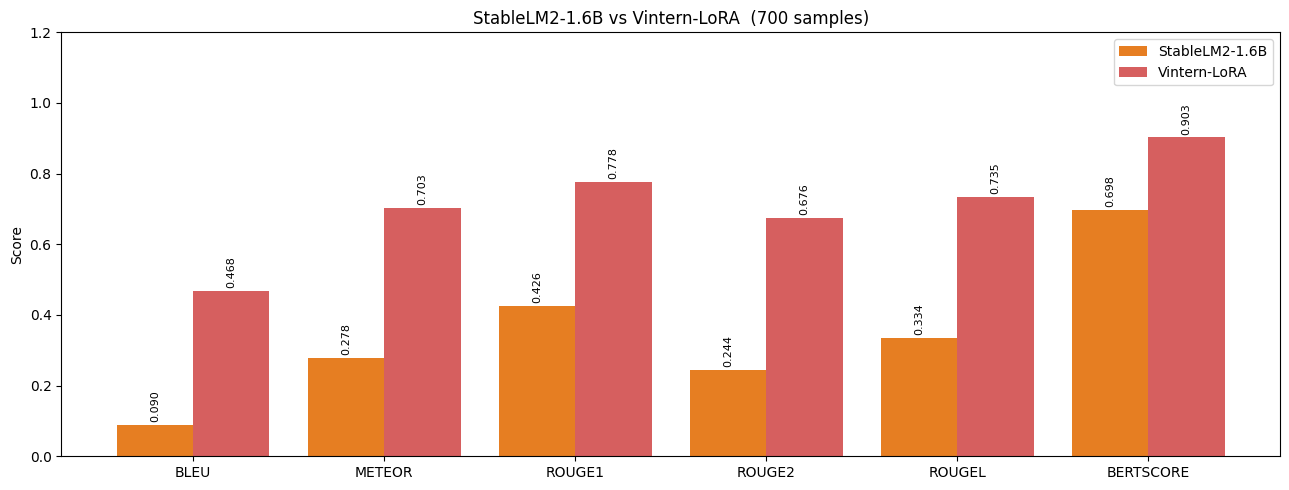

Saved chart: /kaggle/working/eval_stablelm2_vs_vintern_lora.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

all_results = {
    'StableLM2-1.6B': (df_stablelm,  avg_stablelm),
    'Vintern-LoRA':   (df_vintern, avg_vintern),
}

# Bang summary
rows = []
for mname, (_, avg) in all_results.items():
    row = {'Model': mname}
    for m in METRICS:
        row[m.upper()] = round(avg.get(m, 0.0), 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')

def highlight_best(s):
    return ['background-color: #d4edda; font-weight: bold'
            if v == s.max() else '' for v in s]

def highlight_worst(s):
    return ['background-color: #f8d7da'
            if v == s.min() else '' for v in s]

print(f'KET QUA ({EVAL_TOTAL} samples | Xanh = cao nhat | Do = thap nhat)\n')
display(summary_df.style.apply(highlight_best).apply(highlight_worst))

csv_summary = KAGGLE_WORKING / 'eval_stablelm2_vs_vintern_lora.csv'
summary_df.reset_index().to_csv(str(csv_summary), index=False, encoding='utf-8')
print(f'Saved: {csv_summary}')

# Bieu do bar
n      = len(all_results)
x      = np.arange(len(METRICS))
width  = 0.8 / n
colors = ['#e67e22', '#d65f5f']   # cam cho StableLM2, do cho Vintern-LoRA

fig, ax = plt.subplots(figsize=(13, 5))
for idx, (mname, (_, avg)) in enumerate(all_results.items()):
    offset = idx * width - (n - 1) * width / 2
    vals   = [avg.get(m, 0.0) for m in METRICS]
    bars   = ax.bar(x + offset, vals, width, label=mname, color=colors[idx])
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in METRICS], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.set_title(f'StableLM2-1.6B vs Vintern-LoRA  ({EVAL_TOTAL} samples)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()

img_path = KAGGLE_WORKING / 'eval_stablelm2_vs_vintern_lora.png'
plt.savefig(str(img_path), dpi=150)
plt.show()
print(f'Saved chart: {img_path}')

## Cell 11 — Phân tích per-sample (delta StableLM2 - Vintern)

In [16]:
import pandas as pd

df_s = df_stablelm[['id', 'question', 'ground_truth', 'response'] + METRICS].copy()
df_v = df_vintern[['id'] + [m for m in METRICS if m in df_vintern.columns]].copy()

df_merged = df_s.merge(df_v, on='id', suffixes=('_stablelm', '_vintern'))
print(f'Merged: {len(df_merged)} samples')

for m in METRICS:
    cs, cv = f'{m}_stablelm', f'{m}_vintern'
    if cs in df_merged.columns and cv in df_merged.columns:
        df_merged[f'delta_{m}'] = df_merged[cs] - df_merged[cv]

print('\nTop 10 StableLM2 vuot troi (delta BERTScore):')
display(df_merged.nlargest(10, 'delta_bertscore')
        [['id', 'question', 'delta_bleu', 'delta_meteor', 'delta_bertscore']])

print('\nTop 10 StableLM2 kem hon (delta BERTScore):')
display(df_merged.nsmallest(10, 'delta_bertscore')
        [['id', 'question', 'delta_bleu', 'delta_meteor', 'delta_bertscore']])

merged_csv = KAGGLE_WORKING / 'debug_stablelm2_vs_vintern_merged.csv'
df_merged.to_csv(str(merged_csv), index=False, encoding='utf-8')
print(f'Saved: {merged_csv}')

Merged: 700 samples

Top 10 StableLM2 vuot troi (delta BERTScore):


,id,question,delta_bleu,delta_meteor,delta_bertscore
480,6a5647a97ec9a1aaa4f5,Tỷ lệ phần trăm phụ nữ trong dân số Lào vào kh...,0.181998,0.421413,0.076909
34,21d1e48876dcc18cc326,Tỷ lệ dân số nông thôn ở quần đảo Faroe vào nă...,0.073818,0.363151,0.047874
131,26ee9c827a1b48f05914,"Vào năm 1966, quốc gia nào có tỷ lệ phụ thuộc ...",0.048040,0.083966,0.034680
60,5d24cf0e2827bf46e485,"Vào năm 1970, số giường bệnh trung bình trên 1...",0.000000,-0.092593,0.019114
121,9f5aa4c06caf46951ea0,Khoảng thời gian nào tỷ lệ giới tính có sự tha...,0.032224,-0.028591,0.010600
490,058a109213df9a031380,Loại dữ liệu nào có giá trị cao nhất trong đồ ...,-0.025258,-0.053425,0.007665
218,0c2dffc435c68f57cd73,Năm nào có số lượng thủ tục xây dựng nhà kho c...,-0.070997,-0.164319,-0.005386
339,d9b696ce48da4d348a7f,Năm nào có tỷ lệ nhập khẩu công nghệ thông tin...,-0.007576,-0.007583,-0.010928
174,33a698f06cecd792e1bb,Vào khoảng năm nào số lượng quân đội ở Myanmar...,0.055076,-0.004717,-0.011627
293,6ec281557fa2b661f32b,Tỷ lệ sinh sản trung bình trong năm 1961 ở các...,-0.009630,-0.076923,-0.018781



Top 10 StableLM2 kem hon (delta BERTScore):


,id,question,delta_bleu,delta_meteor,delta_bertscore
324,c2ba4765ca2b9fa032c6,Từ nào có giá trị cao nhất trong đồ thị và giá...,-0.996119,-0.938735,-0.422769
125,c6e13bfbef8389a99ba2,Quốc gia nào có tỷ lệ giới tính cao nhất theo ...,-0.657078,-0.727525,-0.421545
638,de4b7e635ac5017bda6e_q0,Tỉnh nào có điểm số năng lực cạnh tranh cao nh...,-0.996795,-0.965486,-0.419122
554,d07a3fd6121147538f05_q0,Tỉnh/thành phố nào có điểm số năng lực cạnh tr...,-0.995271,-0.893117,-0.413119
193,f227674876ad644f0cb3,Doanh thu cao nhất trong thời gian này là bao ...,-0.835479,-0.897593,-0.413113
503,52ed98f52ff32bf91644_q0,Nhóm tuổi nào có tỷ lệ người lao động cao nhất...,-0.700924,-0.806366,-0.412007
9,5e3d5ce945bc29b4c733,Thành phố/vùng nào có tỷ lệ tăng trưởng chi ph...,-0.805611,-0.873689,-0.405552
560,ad66fd58f50a65a5cb6c_q0,Tỉnh nào có sản lượng vải thiều cao nhất và sả...,-0.995811,-0.933399,-0.395595
104,cd4eca0f5f8702906eee,Tỷ lệ giới tính nam ở độ tuổi 30 vào năm 1960 ...,-0.127854,-0.238994,-0.393736
674,9ee79f0ab5e9107f8b41_q0,Tỉnh/thành phố nào có số lượng doanh nghiệp mớ...,-0.996255,-0.963529,-0.392464


Saved: /kaggle/working/debug_stablelm2_vs_vintern_merged.csv


## Cell 12 — Histogram phân phối score

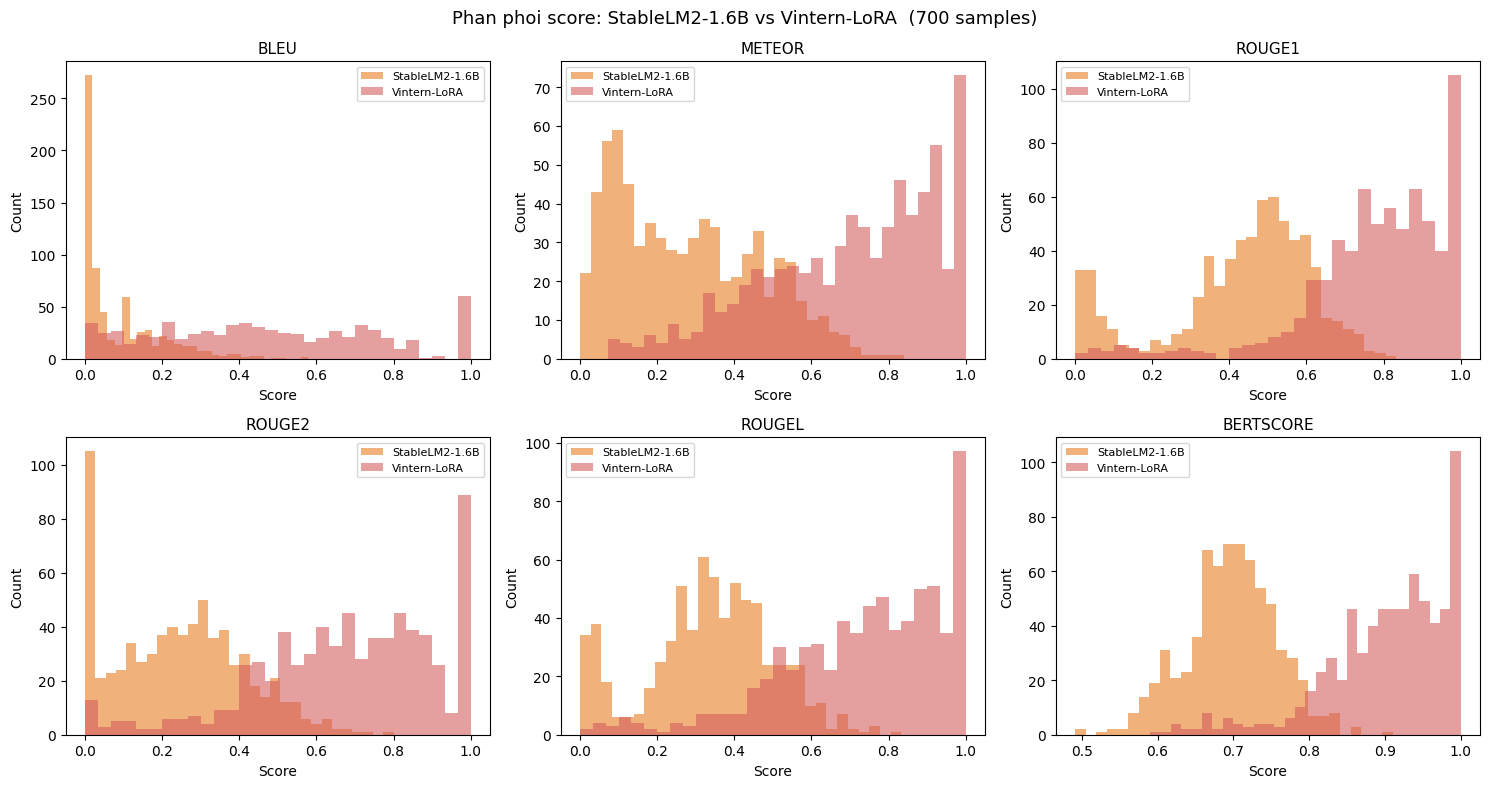

Saved: /kaggle/working/histogram_stablelm2_vs_vintern_lora.png


In [17]:
import matplotlib.pyplot as plt

color_map = {'StableLM2-1.6B': '#e67e22', 'Vintern-LoRA': '#d65f5f'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, m in enumerate(METRICS):
    ax  = axes[i]
    col_s = f'{m}_stablelm'
    col_v = f'{m}_vintern'
    if col_s in df_merged.columns:
        ax.hist(df_merged[col_s], bins=30, alpha=0.6,
                color=color_map['StableLM2-1.6B'], label='StableLM2-1.6B')
    if col_v in df_merged.columns:
        ax.hist(df_merged[col_v], bins=30, alpha=0.6,
                color=color_map['Vintern-LoRA'], label='Vintern-LoRA')
    ax.set_title(m.upper(), fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Phan phoi score: StableLM2-1.6B vs Vintern-LoRA  ({len(df_merged)} samples)',
    fontsize=13,
)
plt.tight_layout()

hist_path = KAGGLE_WORKING / 'histogram_stablelm2_vs_vintern_lora.png'
plt.savefig(str(hist_path), dpi=150)
plt.show()
print(f'Saved: {hist_path}')